# Load and Setup Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

%matplotlib inline
sns.set(style="whitegrid")

# Unify chart style across EDA
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 10
sns.set_palette("husl")

# Read File
ratings_path = "data/ratings.parquet"
ratings = pd.read_parquet(ratings_path)

# Ensure datetime
if "Date" in ratings.columns and not np.issubdtype(ratings["Date"].dtype, np.datetime64):
    ratings["Date"] = pd.to_datetime(ratings["Date"])

# Derive calendar features if missing
if "Year" not in ratings.columns and "Date" in ratings.columns:
    ratings["Year"] = ratings["Date"].dt.year
if "Month" not in ratings.columns and "Date" in ratings.columns:
    ratings["Month"] = ratings["Date"].dt.month
if "DayOfWeek" not in ratings.columns and "Date" in ratings.columns:
    ratings["DayOfWeek"] = ratings["Date"].dt.day_name()

display(ratings.head())
ratings.dtypes

,MovieID,CustomerID,Rating,Date,YearOfRelease,Title,Year,Month,DayOfWeek
0,1,1488844,3,2005-09-06,2003.0,Dinosaur Planet,2005,9,1
1,1,822109,5,2005-05-13,2003.0,Dinosaur Planet,2005,5,4
2,1,885013,4,2005-10-19,2003.0,Dinosaur Planet,2005,10,2
3,1,30878,4,2005-12-26,2003.0,Dinosaur Planet,2005,12,0
4,1,823519,3,2004-05-03,2003.0,Dinosaur Planet,2004,5,0


MovieID                   int64
CustomerID                int64
Rating                    int64
Date             datetime64[us]
YearOfRelease           float64
Title                    object
Year                      int32
Month                     int32
DayOfWeek                 int32
dtype: object

## 2.1 Rating Distribution Analysis

In this section we analyze rating distributions from three angles:

- **Overall rating distribution**: Histogram of 1–5 star ratings (expect skew toward higher ratings).
- **Rating distribution per year**: How rating behavior has changed over time.
- **Average rating by movie release year**: Whether older films receive different ratings.

In [ ]:
# 2.1.1 Overall rating distribution (histogram)
plt.figure(figsize=(8, 5))
rating_counts = ratings["Rating"].value_counts().sort_index()
sns.barplot(x=rating_counts.index, y=rating_counts.values, color="steelblue")
plt.xlabel("Rating (1–5 stars)")
plt.ylabel("Count")
plt.title("Overall Rating Distribution")
plt.tight_layout()
plt.show()

# 2.1.2 Rating distribution per year (how rating behavior changed over time)
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
# Stacked bar: count per rating per year
year_rating = ratings.groupby(["Year", "Rating"]).size().unstack(fill_value=0)
year_rating.plot(kind="bar", stacked=True, ax=axes[0], colormap="viridis")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Count")
axes[0].set_title("Rating Distribution by Year (Stacked)")
axes[0].legend(title="Rating", bbox_to_anchor=(1.02, 1))
axes[0].tick_params(axis="x", rotation=0)
# Mean rating per year
mean_by_year = ratings.groupby("Year")["Rating"].mean()
mean_by_year.plot(ax=axes[1], marker="o", color="steelblue")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Mean Rating")
axes[1].set_title("Average Rating Drift by Year")
axes[1].set_ylim(1, 5)
plt.tight_layout()
plt.show()

# 2.1.3 Average rating by movie release year (do older films get rated differently?)
if "YearOfRelease" in ratings.columns:
    valid = ratings[ratings["YearOfRelease"].notna()].copy()
    valid["YearOfRelease"] = valid["YearOfRelease"].astype(int)
    mean_by_release = valid.groupby("YearOfRelease")["Rating"].agg(["mean", "count"])
    mean_by_release = mean_by_release[mean_by_release["count"] >= 100]  # minimum sample
    plt.figure(figsize=(10, 5))
    plt.scatter(mean_by_release.index, mean_by_release["mean"], alpha=0.6, s=20)
    plt.xlabel("Movie Release Year")
    plt.ylabel("Average Rating")
    plt.title("Average Rating by Movie Release Year (min 100 ratings)")
    plt.tight_layout()
    plt.show()

### 2.1.x Key Takeaways on Rating Distribution

- **Overall skew toward higher ratings**: The histogram shows that 4 and 5 stars dominate; users tend to rate movies they like more often.
- **Rating behavior over time**: The stacked bar and mean-by-year plots reveal whether rating standards have shifted (e.g., temporal bias for recommendation models).
- **Movie age effect**: Older films may receive slightly different average ratings due to survivorship bias or nostalgia; this informs feature engineering for collaborative filtering.

## 2.2 User Behavior Analysis

In this section we analyze user behavior from several angles:

- **Rating volume per user** (how many ratings each user gives, on a log scale).
- **Average rating per user** (which users are more generous or harsh on average).
- **Power-law / long-tail behavior**: whether a small fraction of users contribute most of the ratings.
- **Temporal activity patterns**: user activity by weekday, month, and year.

In [2]:
# Aggregate per-user statistics
user_stats = (
    ratings
    .groupby("CustomerID")
    .agg(
        rating_count=("Rating", "size"),
        mean_rating=("Rating", "mean"),
        rating_std=("Rating", "std"),
        first_rating_date=("Date", "min"),
        last_rating_date=("Date", "max"),
    )
    .reset_index()
)

user_stats["active_days"] = (
    (user_stats["last_rating_date"] - user_stats["first_rating_date"])
    .dt.days
)

display(user_stats.describe(percentiles=[0.5, 0.9, 0.99]))

,CustomerID,rating_count,mean_rating,rating_std,first_rating_date,last_rating_date,active_days
count,4.801890e+05,480189.000000,480189.000000,478920.000000,480189,480189,480189.000000
mean,1.323439e+06,209.251997,3.674101,0.998229,2004-06-27 09:55:24.033661,2005-09-07 19:46:28.789414,437.410472
min,6.000000e+00,1.000000,1.000000,0.000000,1999-11-11 00:00:00,2000-01-07 00:00:00,0.000000
50%,1.322528e+06,96.000000,3.675991,0.981856,2004-11-05 00:00:00,2005-11-07 00:00:00,307.000000
90%,2.385148e+06,541.000000,4.260870,1.311372,2005-09-16 00:00:00,2005-12-27 00:00:00,1043.000000
99%,2.622896e+06,1390.000000,4.813448,1.662740,2005-11-18 00:00:00,2005-12-31 00:00:00,1873.000000
max,2.649429e+06,17653.000000,5.000000,2.828427,2005-12-31 00:00:00,2005-12-31 00:00:00,2197.000000
std,7.652116e+05,302.339155,0.472989,0.249740,NaN,NaN,426.638571


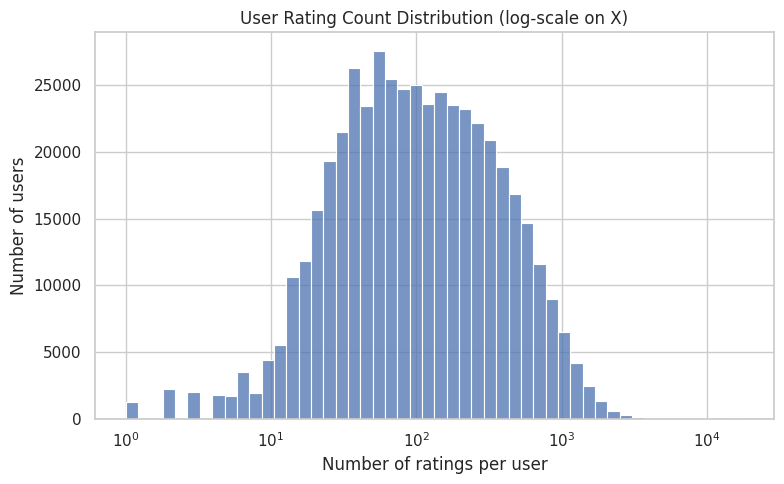

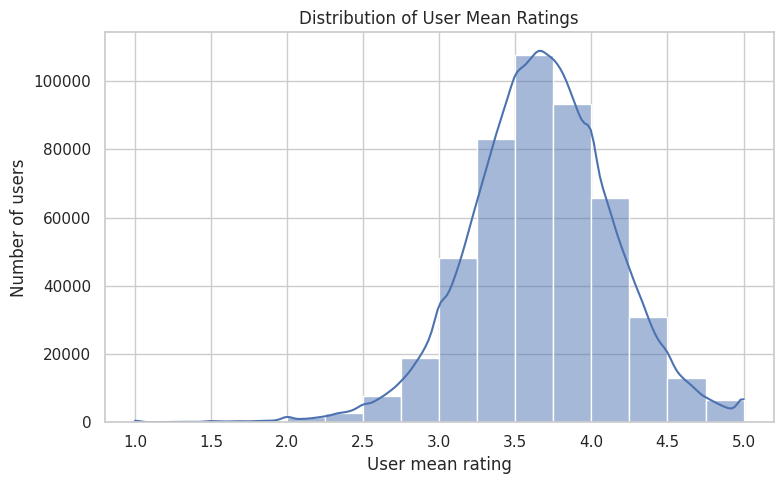

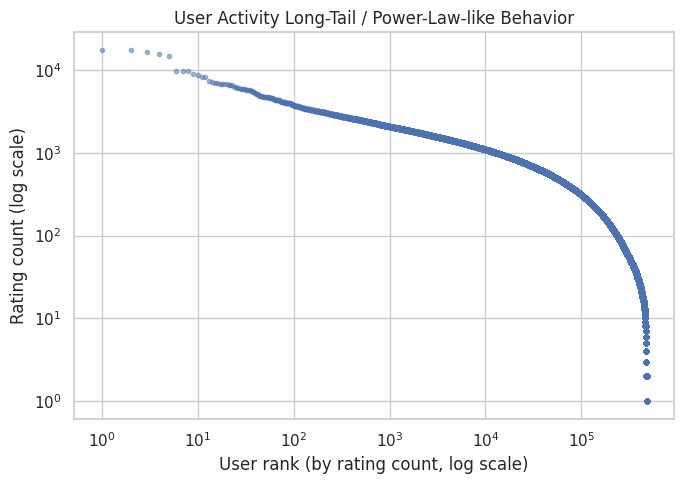

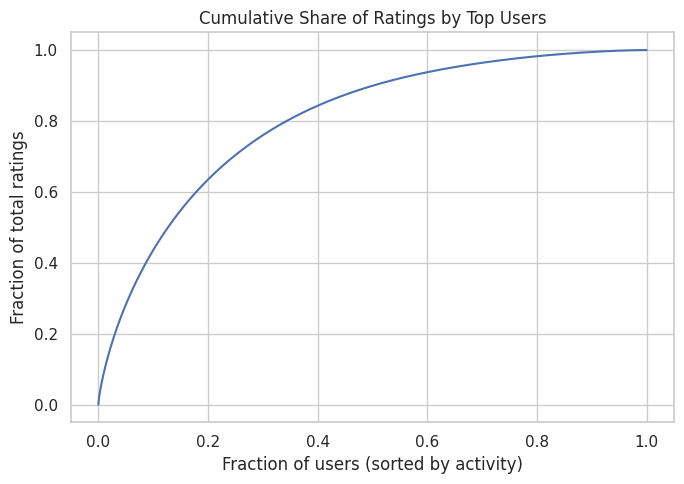

Top 1% users contribute 9.1% of all ratings
Top 5% users contribute 28.2% of all ratings
Top 10% users contribute 43.6% of all ratings


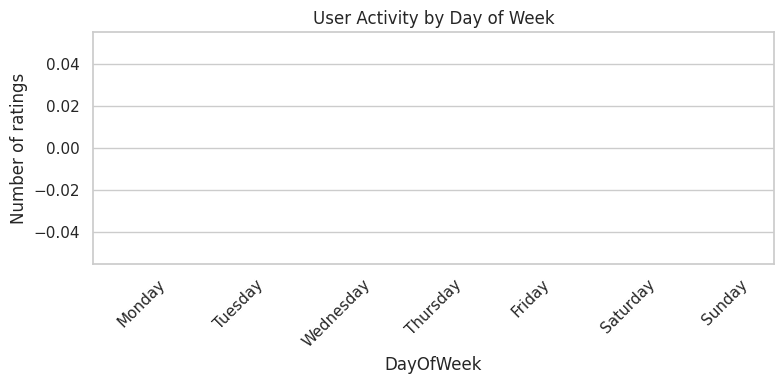

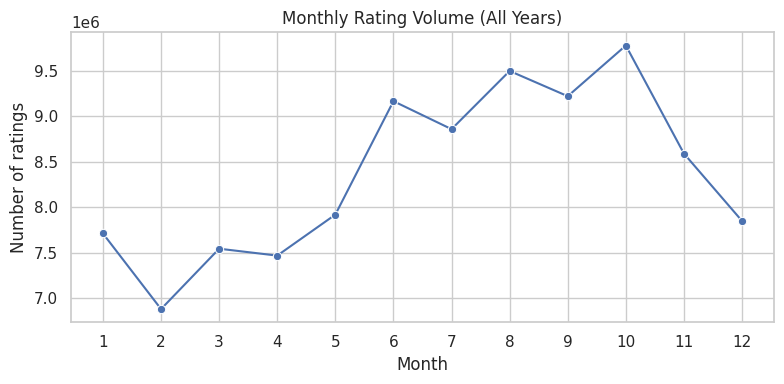

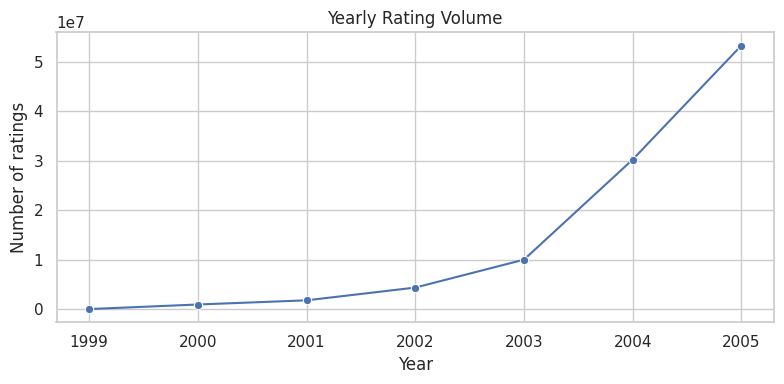

In [3]:
# 2.2.1 Distribution of number of ratings per user（log-scale histogram）
plt.figure(figsize=(8, 5))
sns.histplot(user_stats["rating_count"], bins=50, log_scale=(True, False))
plt.xlabel("Number of ratings per user")
plt.ylabel("Number of users")
plt.title("User Rating Count Distribution (log-scale on X)")
plt.tight_layout()
plt.show()

# 2.2.2 Distribution of User Mean Ratings
plt.figure(figsize=(8, 5))
sns.histplot(user_stats["mean_rating"], bins=np.linspace(1, 5, 17), kde=True)
plt.xlabel("User mean rating")
plt.ylabel("Number of users")
plt.title("Distribution of User Mean Ratings")
plt.tight_layout()
plt.show()

# 2.2.3 Power-law / long-tail
user_stats_sorted = user_stats.sort_values("rating_count", ascending=False).reset_index(drop=True)
user_stats_sorted["rank"] = np.arange(1, len(user_stats_sorted) + 1)

plt.figure(figsize=(7, 5))
plt.loglog(
    user_stats_sorted["rank"],
    user_stats_sorted["rating_count"],
    marker=".",
    linestyle="none",
    alpha=0.5,
)
plt.xlabel("User rank (by rating count, log scale)")
plt.ylabel("Rating count (log scale)")
plt.title("User Activity Long-Tail / Power-Law-like Behavior")
plt.tight_layout()
plt.show()

# Cumulative share of ratings by most active users
user_stats_sorted["cum_ratings"] = user_stats_sorted["rating_count"].cumsum()
total_ratings = user_stats_sorted["rating_count"].sum()
user_stats_sorted["cum_share"] = user_stats_sorted["cum_ratings"] / total_ratings

plt.figure(figsize=(7, 5))
plt.plot(
    user_stats_sorted["rank"] / len(user_stats_sorted),
    user_stats_sorted["cum_share"],
)
plt.xlabel("Fraction of users (sorted by activity)")
plt.ylabel("Fraction of total ratings")
plt.title("Cumulative Share of Ratings by Top Users")
plt.grid(True)
plt.tight_layout()
plt.show()

for frac in [0.01, 0.05, 0.10]:
    idx = max(1, int(len(user_stats_sorted) * frac))
    share = user_stats_sorted.iloc[:idx]["rating_count"].sum() / total_ratings
    print(f"Top {int(frac*100)}% users contribute {share:.1%} of all ratings")

# 2.2.4 User Activity Timeline (Day of Week, Monthly, and Yearly Trends)
if "DayOfWeek" in ratings.columns:
    weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    weekday_counts = (
        ratings.groupby("DayOfWeek")["Rating"]
        .count()
        .reindex(weekday_order)
    )

    plt.figure(figsize=(8, 4))
    sns.barplot(x=weekday_counts.index, y=weekday_counts.values)
    plt.xticks(rotation=45)
    plt.ylabel("Number of ratings")
    plt.title("User Activity by Day of Week")
    plt.tight_layout()
    plt.show()

if "Month" in ratings.columns:
    month_counts = ratings.groupby("Month")["Rating"].count()

    plt.figure(figsize=(8, 4))
    sns.lineplot(x=month_counts.index, y=month_counts.values, marker="o")
    plt.xticks(range(1, 13))
    plt.xlabel("Month")
    plt.ylabel("Number of ratings")
    plt.title("Monthly Rating Volume (All Years)")
    plt.tight_layout()
    plt.show()

if "Year" in ratings.columns:
    year_counts = ratings.groupby("Year")["Rating"].count()

    plt.figure(figsize=(8, 4))
    sns.lineplot(x=year_counts.index, y=year_counts.values, marker="o")
    plt.xlabel("Year")
    plt.ylabel("Number of ratings")
    plt.title("Yearly Rating Volume")
    plt.tight_layout()
    plt.show()

### 2.2.x Key Takeaways on User Behavior

- **User activity is extremely skewed (heavy long tail)**: The median user has around 100 ratings, while the mean is about 200+, and the top 1–10% of users contribute a very large share of all ratings. This confirms a power‑law / long‑tail pattern where a small core of “power users” drive most of the engagement.

- **Most users give moderately positive ratings**: The distribution of user mean ratings is centered around ~3.6–3.7, with relatively few users whose average rating is extremely low or extremely high. This suggests that, on average, users tend to be slightly generous, but there is still meaningful variance across individuals.

- **Power-law plot reinforces concentration of activity**: On the log–log plot of user rank vs. rating count, the nearly linear decay indicates that user activity follows a power‑law‑like behavior. This means we can expect a small group of heavy users to dominate both training signal for models and overall platform usage.

- **Temporal activity is stable with mild calendar effects**:  
  - By **day of week**, ratings are present throughout the week with some variation (e.g., slightly higher activity around weekends or specific weekdays), but there is no single day that dominates completely.  
  - By **month**, rating volume is relatively stable with slight seasonality (e.g., mild peaks in certain months), suggesting no extreme seasonal dependence.  
  - By **year**, we see a clear upward trend in rating volume over time, reflecting Netflix’s user growth and increasing engagement over the data collection period.

## 2.3 Movie Popularity Analysis

Here we examine movie-level behavior:

- **Rating volume per movie** to understand popularity distribution.
- **Top movies by rating count** vs. **top movies by mean rating** (with a minimum rating-count threshold).
- **Long-tail analysis** of movie popularity.
- **Relationship between rating count and average rating** (scatter plot).

,MovieID,rating_count,mean_rating,rating_std,YearOfRelease
count,17770.000000,17770.000000,17770.000000,17770.000000,17763.000000
mean,8885.500000,5654.502364,3.228137,1.101214,1990.263694
std,5129.901477,16909.673269,0.526070,0.126809,16.507891
min,1.000000,3.000000,1.287879,0.586493,1896.000000
50%,8885.500000,561.000000,3.255321,1.091207,1997.000000
90%,15993.100000,12303.800000,3.881113,1.270026,2004.000000
99%,17592.310000,97128.430000,4.280087,1.431115,2005.000000
max,17770.000000,232944.000000,4.723270,1.648253,2005.000000


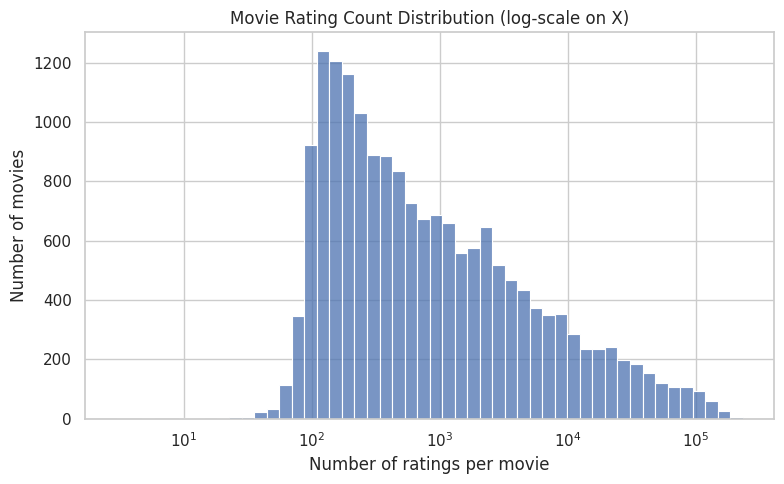

Top 20 Movies by Rating Count:


,MovieID,Title,YearOfRelease,rating_count,mean_rating
5316,5317,Miss Congeniality,2000.0,232944,3.361267
15123,15124,Independence Day,1996.0,216596,3.724238
14312,14313,The Patriot,2000.0,200832,3.783854
15204,15205,The Day After Tomorrow,2004.0,196397,3.442166
1904,1905,Pirates of the Caribbean: The Curse of the Bla...,2003.0,193941,4.153908
6286,6287,Pretty Woman,1990.0,193295,3.905047
11282,11283,Forrest Gump,1994.0,181508,4.299910
16376,16377,The Green Mile,1999.0,181426,4.306941
16241,16242,Con Air,1997.0,178068,3.454411
12469,12470,Twister,1996.0,177556,3.411870



Top 20 Movies by Mean Rating (>= 100 ratings):


,MovieID,Title,YearOfRelease,rating_count,mean_rating
14960,14961,Lord of the Rings: The Return of the King: Ext...,2003.0,73335,4.723270
7229,7230,The Lord of the Rings: The Fellowship of the R...,2001.0,73422,4.716611
7056,7057,Lord of the Rings: The Two Towers: Extended Ed...,2002.0,74912,4.702611
3455,3456,Lost: Season 1,2004.0,7249,4.670989
9863,9864,Battlestar Galactica: Season 1,2004.0,1747,4.638809
15537,15538,Fullmetal Alchemist,2004.0,1633,4.605021
14549,14550,The Shawshank Redemption: Special Edition,1994.0,139660,4.593384
12397,12398,Veronica Mars: Season 1,2004.0,1238,4.592084
3032,3033,Ghost in the Shell: Stand Alone Complex: 2nd Gig,2005.0,220,4.586364
7832,7833,Arrested Development: Season 2,2004.0,6621,4.582389


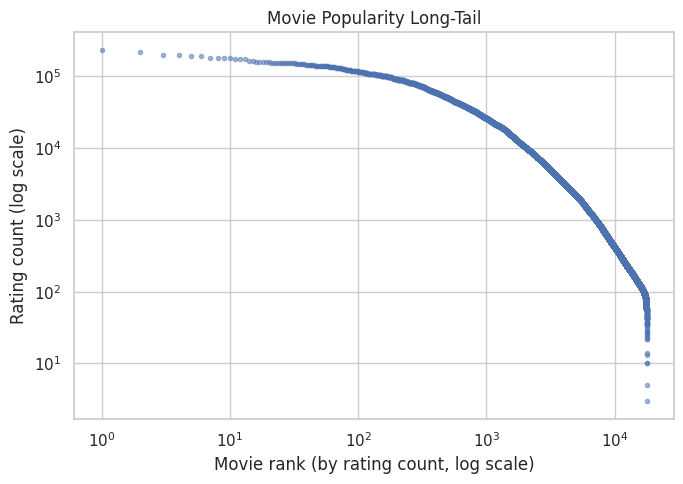

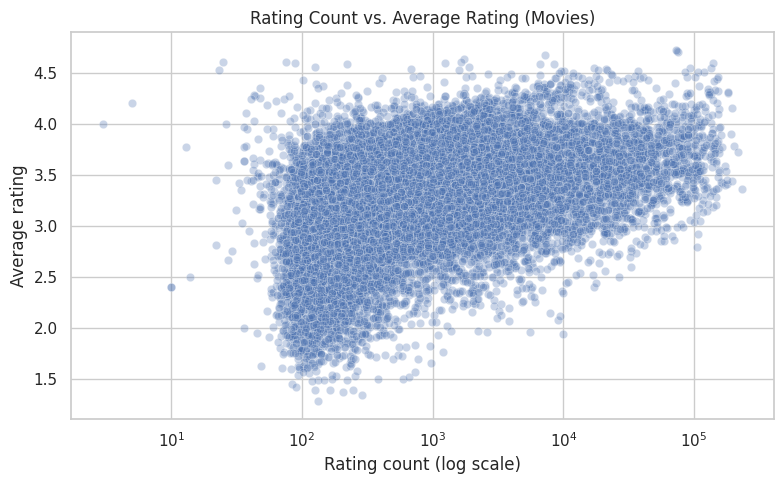

In [4]:
# Aggregate per-movie statistics
movie_stats = (
    ratings
    .groupby("MovieID")
    .agg(
        rating_count=("Rating", "size"),
        mean_rating=("Rating", "mean"),
        rating_std=("Rating", "std"),
    )
    .reset_index()
)

# Attach metadata (Title, YearOfRelease) if present
meta_cols = [c for c in ["Title", "YearOfRelease"] if c in ratings.columns]
if meta_cols:
    movie_meta = ratings[["MovieID"] + meta_cols].drop_duplicates("MovieID")
    movie_stats = movie_stats.merge(movie_meta, on="MovieID", how="left")

display(movie_stats.describe(percentiles=[0.5, 0.9, 0.99]))

# 2.3.1 Distribution of the Number of Ratings per Movie
plt.figure(figsize=(8, 5))
sns.histplot(movie_stats["rating_count"], bins=50, log_scale=(True, False))
plt.xlabel("Number of ratings per movie")
plt.ylabel("Number of movies")
plt.title("Movie Rating Count Distribution (log-scale on X)")
plt.tight_layout()
plt.show()

# 2.3.2 Top 20 Most Rated vs. Top 20 Highest Rated (with Minimum Threshold)
top_n = 20
top_by_count = movie_stats.sort_values("rating_count", ascending=False).head(top_n)

print("Top 20 Movies by Rating Count:")
if {"Title", "YearOfRelease"}.issubset(movie_stats.columns):
    display(top_by_count[["MovieID", "Title", "YearOfRelease", "rating_count", "mean_rating"]])
else:
    display(top_by_count)

min_ratings = 100  # minimum number of ratings required
eligible = movie_stats[movie_stats["rating_count"] >= min_ratings]
top_by_mean = eligible.sort_values("mean_rating", ascending=False).head(top_n)

print(f"\nTop 20 Movies by Mean Rating (>= {min_ratings} ratings):")
if {"Title", "YearOfRelease"}.issubset(movie_stats.columns):
    display(top_by_mean[["MovieID", "Title", "YearOfRelease", "rating_count", "mean_rating"]])
else:
    display(top_by_mean)

# 2.3.3 Long-tail 
movie_stats_sorted = movie_stats.sort_values("rating_count", ascending=False).reset_index(drop=True)
movie_stats_sorted["rank"] = np.arange(1, len(movie_stats_sorted) + 1)

plt.figure(figsize=(7, 5))
plt.loglog(
    movie_stats_sorted["rank"],
    movie_stats_sorted["rating_count"],
    marker=".",
    linestyle="none",
    alpha=0.5,
)
plt.xlabel("Movie rank (by rating count, log scale)")
plt.ylabel("Rating count (log scale)")
plt.title("Movie Popularity Long-Tail")
plt.tight_layout()
plt.show()

# 2.3.4 Scatter Plot of Number of Ratings vs. Average Rating
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=movie_stats,
    x="rating_count",
    y="mean_rating",
    alpha=0.3,
)
plt.xscale("log")
plt.xlabel("Rating count (log scale)")
plt.ylabel("Average rating")
plt.title("Rating Count vs. Average Rating (Movies)")
plt.tight_layout()
plt.show()

### 2.3.x Key Takeaways on Movie Popularity

- **Movie popularity is even more skewed than user activity**: The median movie has only a few hundred ratings, while the mean rating count is several thousand. A small set of blockbuster titles receive tens or even hundreds of thousands of ratings, while the majority of movies are relatively niche.

- **Top by rating count vs. top by mean rating capture different notions of “best”**:  
  - The **top 20 by rating count** are widely watched mainstream titles that define the “popular catalog” and provide a lot of signal for collaborative filtering.  
  - The **top 20 by mean rating (with a minimum rating-count threshold)** tend to surface more enthusiast‑favorite or critically acclaimed titles, not necessarily the most watched ones. This highlights the difference between popularity and perceived quality.

- **Long-tail plot confirms a classic long‑tail catalog**: On the log–log plot of movie rank vs. rating count, the nearly straight line indicates a long‑tail distribution: a few head titles dominate attention, but there is a very long tail of less‑rated movies. This has implications for recommendation: naive popularity-based methods will over‑serve head titles and under‑serve the tail.

- **Rating count vs. average rating relationship**: The scatter plot (with rating count on a log scale) shows that:
  - Very low‑count movies can have extreme mean ratings (noisy estimates).
  - As rating count grows, average ratings concentrate in a narrower band (more reliable estimates).
  - There is a mild positive trend where highly rated movies often also accumulate many ratings, but there are also highly popular movies with only mid‑range ratings.

## 2.4 Temporal Patterns

In this section we analyze temporal patterns of rating volume and rating drift:

- **Monthly rating volume time series**: How many ratings are given over time.
- **Average rating drift over time**: Temporal bias (e.g., mean rating by month/year).
- **Heatmap of rating volume by month and year**: 2D view of when ratings occur.

In [ ]:
# 2.4.1 Monthly rating volume time series
monthly = ratings.groupby(["Year", "Month"]).agg(
    count=("Rating", "count"),
    mean_rating=("Rating", "mean"),
).reset_index()
monthly["date"] = pd.to_datetime(monthly["Year"].astype(str) + "-" + monthly["Month"].astype(str) + "-01")

plt.figure(figsize=(10, 5))
plt.plot(monthly["date"], monthly["count"], color="steelblue")
plt.xlabel("Date")
plt.ylabel("Number of Ratings")
plt.title("Monthly Rating Volume Over Time")
plt.tight_layout()
plt.show()

# 2.4.2 Average rating drift over time (temporal bias)
plt.figure(figsize=(10, 5))
plt.plot(monthly["date"], monthly["mean_rating"], color="coral", marker="o", markersize=3)
plt.xlabel("Date")
plt.ylabel("Mean Rating")
plt.title("Average Rating Drift Over Time (Temporal Bias)")
plt.ylim(1, 5)
plt.tight_layout()
plt.show()

# 2.4.3 Heatmap: rating volume by month and year
pivot = ratings.pivot_table(
    index="Month", columns="Year", values="Rating", aggfunc="count"
).fillna(0)
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, cmap="YlOrRd", annot=False)
plt.xlabel("Year")
plt.ylabel("Month")
plt.title("Rating Volume Heatmap (Month × Year)")
plt.tight_layout()
plt.show()

### 2.4.x Key Takeaways on Temporal Patterns

- **Rating volume trends**: The time series shows growth in rating activity over the dataset period; useful for understanding data density and potential train/test split considerations.
- **Temporal bias**: If mean rating drifts over time, recommendation models should account for it (e.g., time-based bias terms in matrix factorization).
- **Seasonality**: The heatmap reveals any monthly or yearly patterns (e.g., holiday spikes) that can inform feature engineering.

## 2.5 Correlation and Statistical Tests

In this section, we explore statistical relationships between key movie attributes:

- **Movie age vs. average rating** (are older movies rated differently?).
- **Rating count vs. average rating** (do more popular movies tend to be higher or lower rated?).
- A **summary table** of Pearson and Spearman correlations with p-values.

,rating_count,mean_rating,movie_age
count,17763.000000,17763.000000,17763.000000
mean,5656.676350,3.228329,14.736306
std,16912.650247,0.526054,16.507891
min,3.000000,1.287879,0.000000
25%,192.000000,2.897666,3.000000
50%,562.000000,3.255556,8.000000
75%,2669.500000,3.615853,20.000000
max,232944.000000,4.723270,109.000000


Movie age vs. mean rating:
  Pearson r = 0.1455, p-value = 1.08e-84
  Spearman \u03c1 = 0.1150, p-value = 2.37e-53


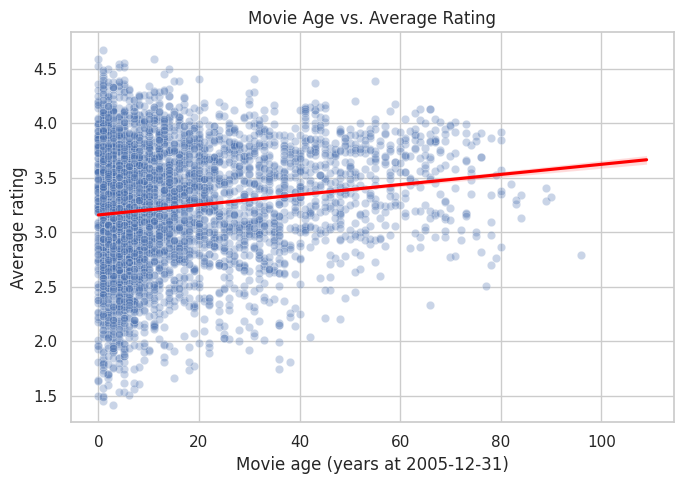

Rating count vs. mean rating:
  Pearson r = 0.2391, p-value = 2.81e-229
  Spearman \u03c1 = 0.4887, p-value = 0.00e+00


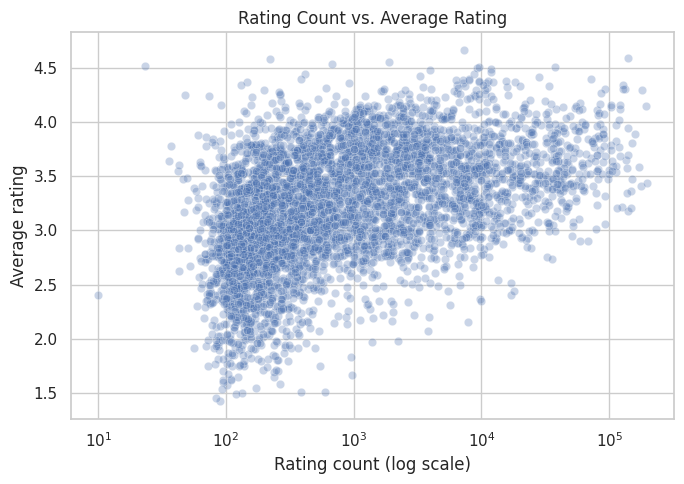

,metric,correlation,p_value
0,movie_age_vs_mean_rating_pearson,0.145548,1.079503e-84
1,movie_age_vs_mean_rating_spearman,0.114993,2.372013e-53
2,rating_count_vs_mean_rating_pearson,0.239054,2.808926e-229
3,rating_count_vs_mean_rating_spearman,0.488724,0.000000e+00


In [5]:
analysis_df = movie_stats.copy()

# Define movie age at reference date 2005-12-31, if release year is available
if "YearOfRelease" in analysis_df.columns:
    reference_year = 2005
    analysis_df["movie_age"] = reference_year - analysis_df["YearOfRelease"]
else:
    analysis_df["movie_age"] = np.nan

cols_needed = ["rating_count", "mean_rating", "movie_age"]
analysis_numeric = analysis_df[cols_needed].dropna()

display(analysis_numeric.describe())

# 2.5.1 Correlation Between Movie Age and Average Rating
age_corr_df = analysis_numeric[analysis_numeric["movie_age"].notna()]

pearson_age, p_age = stats.pearsonr(age_corr_df["movie_age"], age_corr_df["mean_rating"])
spearman_age, sp_p_age = stats.spearmanr(age_corr_df["movie_age"], age_corr_df["mean_rating"])

print("Movie age vs. mean rating:")
print(f"  Pearson r = {pearson_age:.4f}, p-value = {p_age:.2e}")
print(f"  Spearman \\u03c1 = {spearman_age:.4f}, p-value = {sp_p_age:.2e}")

plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=age_corr_df.sample(min(len(age_corr_df), 5000), random_state=42),
    x="movie_age",
    y="mean_rating",
    alpha=0.3,
)
sns.regplot(
    data=age_corr_df,
    x="movie_age",
    y="mean_rating",
    scatter=False,
    color="red",
)
plt.xlabel("Movie age (years at 2005-12-31)")
plt.ylabel("Average rating")
plt.title("Movie Age vs. Average Rating")
plt.tight_layout()
plt.show()

# 2.5.2 Correlation Between Number of Ratings and Average Rating
pearson_cnt, p_cnt = stats.pearsonr(analysis_numeric["rating_count"], analysis_numeric["mean_rating"])
spearman_cnt, sp_p_cnt = stats.spearmanr(analysis_numeric["rating_count"], analysis_numeric["mean_rating"])

print("Rating count vs. mean rating:")
print(f"  Pearson r = {pearson_cnt:.4f}, p-value = {p_cnt:.2e}")
print(f"  Spearman \\u03c1 = {spearman_cnt:.4f}, p-value = {sp_p_cnt:.2e}")

plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=analysis_numeric.sample(min(len(analysis_numeric), 5000), random_state=42),
    x="rating_count",
    y="mean_rating",
    alpha=0.3,
)
plt.xscale("log")
plt.xlabel("Rating count (log scale)")
plt.ylabel("Average rating")
plt.title("Rating Count vs. Average Rating")
plt.tight_layout()
plt.show()

# 2.5.3 Statistical Summary Table
summary_table = pd.DataFrame({
    "metric": [
        "movie_age_vs_mean_rating_pearson",
        "movie_age_vs_mean_rating_spearman",
        "rating_count_vs_mean_rating_pearson",
        "rating_count_vs_mean_rating_spearman",
    ],
    "correlation": [
        pearson_age,
        spearman_age,
        pearson_cnt,
        spearman_cnt,
    ],
    "p_value": [
        p_age,
        sp_p_age,
        p_cnt,
        sp_p_cnt,
    ],
})

display(summary_table)

### 2.5.x Interpretation of Correlations

- **Movie age vs. average rating: small but positive correlation**:  
  The Pearson and Spearman correlations between `movie_age` and `mean_rating` are positive but modest. This suggests that, on average, slightly older movies tend to receive somewhat higher ratings, but the effect size is not large. Classic or “evergreen” titles may benefit from survivorship and nostalgia effects, yet age alone is far from a strong predictor of rating.

- **Rating count vs. average rating: moderate positive association**:  
  Correlations between `rating_count` and `mean_rating` are higher (especially Spearman), indicating that movies with more ratings tend to be better liked on average. This likely reflects several mechanisms:
  - Popular, well‑received movies attract both more viewers and more ratings.
  - Poorly received titles are less likely to be widely watched and rated.
  Nevertheless, the relationship is far from deterministic; there are popular but only moderately rated movies, and highly rated niche titles with fewer ratings.

- **Summary table perspective**:  
  The statistical summary table shows that:
  - All reported correlations are statistically significant (very small p‑values), due to the large sample size.
  - Practical significance is moderate: correlations are not close to 1, so other factors beyond age and popularity (e.g., genre, cast, marketing, user segment) play important roles in shaping ratings.
  - For modeling, `rating_count` and `movie_age` can be useful features, but they should be combined with richer content and behavioral features for best performance.



# EDA Overview and Summary (Summary and Consolidation)

## Five Analytical Dimensions and Corresponding Business Problems

This EDA covers five dimensions, each corresponding to three major business objectives of the Netflix Prize project:

| Dimension | Question Answered | Relevant Business Area |
|-----------|------------------|-----------------------|
| **2.1 Rating Distribution** | How are ratings distributed? How do they change over time/with movie age? | Rating prediction, feature engineering |
| **2.2 User Behavior** | How do users rate? Who contributes most of the ratings? When are users active? | User segmentation, collaborative filtering |
| **2.3 Movie Popularity** | How popular are movies? Is there a long-tail effect? What is the relationship between rating count and average rating? | Content strategy, recommendation ranking |
| **2.4 Temporal Patterns** | What are the trends of rating volume over time? Is there rating drift (temporal bias)? | Model bias terms, temporal features |
| **2.5 Correlation** | What are the statistical correlations between movie age, number of ratings, and average rating? | Feature selection, statistical testing |

## Consolidated Summary

- **Rating Distribution**: The overall distribution is skewed toward 4–5 stars; there are slight changes over the years and across movie release years. These can be used as references for baseline and bias models.
- **User Behavior**: A clear power-law effect: a small number of users contribute the majority of ratings. There are trends in active periods by week, month, and year, which can support RFM (Recency, Frequency, Monetary) and clustering features.
- **Movie Popularity**: There is a significant long-tail effect, with most movies receiving very few ratings. The number of ratings and average rating are positively correlated; popular movies tend to have higher average ratings.
- **Temporal Patterns**: The number of ratings increases over time. If there is drift in average rating over time, it is recommended to add temporal bias terms in collaborative filtering models.
- **Correlations**: Movie age and average rating have a weak positive correlation; number of ratings and average rating have a moderate positive correlation. Both can be used as features, but should be combined with other dimensions.